# APR + Phasor Workflow

Runs the full phasor calibration and lifetime analysis pipeline.
An optional **Adaptive Pixel Reassignment (APR)** step can be enabled
via the `DO_APR` flag in the parameters cell: the reassigned data overwrites
`data_input` in memory before phasor computation, so no intermediate file is needed.

## Imports

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

# Phasor Workflow
import brighteyes_flim.tools_phasor as flim
import brighteyes_flim.graph_tools as graph
from brighteyes_mcs_file import Alignment, calibrate_h5_file, show_h5_structure_html, load_default_irf, load_default_output_spad, load_default_ref



## Parameters

Edit only this cell before running the notebook.

In [2]:
# ── File paths ────────────────────────────────────────────────────────────

FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/Giuse2/Test_01_large_DFD.h5'

DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')
CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}[DATA_KEY]
INSPECT_DATA_KEY = DATA_KEY

# ── Calibration parameters ─────────────────────────────────────────────────

TAU_REF              = None
REFERENCE_TYPE       = "ref"
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

# ── APR parameters ─────────────────────────────────────────────────────────

# Set to True to apply pixel reassignment before phasor computation
DO_APR = True

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to keep the full field of view
ROI = None #(1000, 1750, 1200, 1950)

# Index of the central detector element used as the reassignment reference
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift-vector (higher = more accurate but slower)
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"




## Calibration

In [3]:
FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)



Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/Giuse2/Test_01_large_DFD_calib.h5


## Load Calibrated Data

In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                  = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    irf_common_delay_realigned  = calibration["aligned/irf_trace"][:]
    ref_common_delay_realigned  = calibration["aligned/reference_trace"][:]

    data_summed = load_default_output_spad(hf, selection=np.s_[0, 0, ...])
    irf_summed  = load_default_irf(hf)
    ref_summed  = load_default_ref(hf)

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")




Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


## Photon Flux Per SPAD Channel

In [5]:
# n_foton_per_channel: shape (25,) — fotoni totali per canale SPAD sommati su rep, frame, x, y e timebin
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = data_input.shape[0], data_input.shape[1], data_input.shape[2], data_input.shape[3]
n_px_total = n_rep * n_frame * nx * ny

# Flusso per canale [Hz] = fotoni totali per canale / tempo totale di misura
total_time_s = n_px_total * pxdwelltime * 1e-6
flux_per_channel = n_foton_per_channel / total_time_s  # shape: (25,)

# Flusso medio su tutti i canali
flux_total = flux_per_channel.sum()

print(f"Pixel dwell time:     {pxdwelltime:.3f} µs")
print(f"Total time of acquisition:  {total_time_s:.4f} s")
print(f"Mean flux total:  {flux_total * 1e-3:.2f} kHz")
print(f"Mean flux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val *1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")



Pixel dwell time:     182.000 µs
Total time of acquisition:  47.7102 s
Mean flux total:  1682.32 kHz
Mean flux per channel (kHz):
43.01   54.15   59.78   55.78   45.26   
56.82   77.07   86.99   77.21   62.37   
66.45   92.89   103.97  89.26   63.19   
61.93   84.02   91.70   78.57   57.08   
48.62   60.30   64.53   56.59   44.80   


## APR — Pixel Reassignment *(optional)*

Controlled by `DO_APR` in the parameters cell.
When enabled, `data_input` is overwritten in memory with the spatially-reassigned
version before phasor computation; everything downstream is unaffected.

Shift vectors (dy, dx) per channel:
[[-184.73581213 -101.76125245]
 [-158.12133072  -20.35225049]
 [-136.2035225    67.31898239]
 [-106.45792564  148.72798434]
 [ -72.01565558  230.1369863 ]
 [-123.67906067 -134.63796477]
 [ -97.06457926  -50.09784736]
 [ -67.31898239   32.87671233]
 [ -40.70450098  114.28571429]
 [ -14.09001957  197.26027397]
 [ -53.22896282 -164.38356164]
 [ -26.61448141  -82.97455969]
 [   0.            0.        ]
 [  25.04892368   84.54011742]
 [  50.09784736  167.5146771 ]
 [  10.95890411 -192.56360078]
 [  40.70450098 -115.85127202]
 [  65.75342466  -31.3111546 ]
 [  89.23679061   51.66340509]
 [ 115.85127202  134.63796477]
 [  76.71232877 -219.17808219]
 [ 106.45792564 -144.03131115]
 [ 129.94129159  -64.18786693]
 [ 156.55577299   20.35225049]
 [ 183.1702544   104.89236791]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


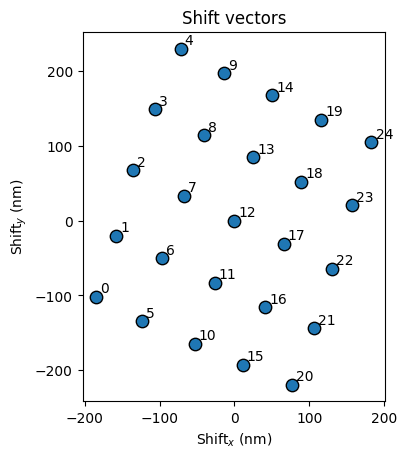

Reassigning time bins: 100%|██████████| 91/91 [01:12<00:00,  1.26it/s]

APR complete — data_input shape: (1, 1, 512, 512, 91, 25)


In [6]:
if DO_APR:

    # Select the first rep and z-plane -> (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Collapse time bins to get the intensity image (y, x, channels),
    # used only for shift-vector estimation
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors between each channel and the reference detector 
    # (one (dy, dx) pair per channel)
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    # Conversione in nm
    pixel_size_nm = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel:")
    print(shift_vectors_nm)
    # Visualise the shift vectors on a grid plot
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Apply reassignment independently for each time bin and overwrite data_input
    n_x, n_y, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, x, y, t_bins, channels) to match the original shape
    data_input = reassigned[np.newaxis, np.newaxis, ...]   # overwrite in memory
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")





## APR — Before / After Intensity Comparison
Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.

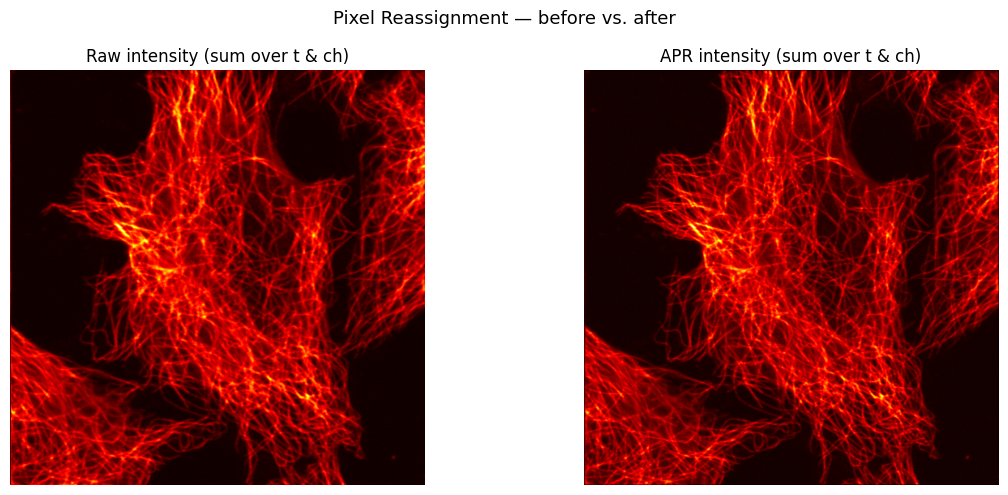

Raw image — min: 17  max: 2037
APR image — min: 5.0  max: 2259.0


In [7]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(intensity_raw, cmap="hot", origin="lower")
    axes[0].set_title("Raw intensity (sum over t & ch)")
    axes[0].axis("off")

    axes[1].imshow(intensity_apr, cmap="hot", origin="lower")
    axes[1].set_title("APR intensity (sum over t & ch)")
    axes[1].axis("off")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
else:
    print("DO_APR = False — skipping before/after comparison.")




## Compute Phasors

In [8]:
# The following 'if' statement is used when REFERENCE_TYPE = 'ref';
# if REFERENCE_TYPE = 'irf', it should be commented out (da verificare)
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor            = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor            = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)


data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)
phasor map: (512, 512)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

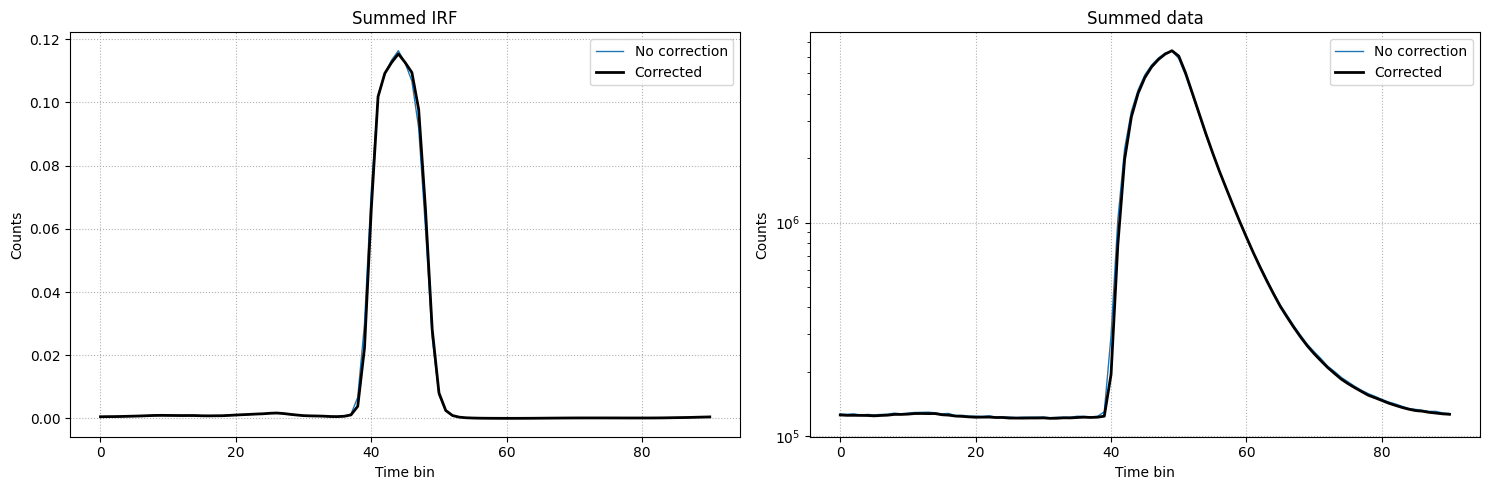

In [9]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
)



## Correct Phasors And Build Lifetime Maps

In [10]:
intensity_map = data_summed.sum(axis=-1)

with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf["calibration/results/spad"]
    tau_reference_ns= calibration["fit/tau_reference_ns"][:]
 
tau_reference_ns_median = np.median(tau_reference_ns)
 

if REFERENCE_TYPE == 'ref':
    # Theoretical phasor of the monoexponential reference sample
    omega = 2 * np.pi * laser_freq_mhz * 1e6          # rad/s
    tau_ref_s = tau_reference_ns_median * 1e-9                          # ns → s
    ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

    # The system response = measured_ref / theoretical_ref
    ref_correction = ref_phasor / ref_phasor_theoretical

    print(f"Ref phasor misurato:  {ref_phasor:.6f}")
    print(f"Ref phasor teorico:   {ref_phasor_theoretical:.6f}")
    print(f"Correction factor:    {ref_correction:.6f}")

else:  # REFERENCE_TYPE == 'irf'
    irf_correction = irf_phasor

    #if  'complex' == "phase_only":
    #    irf_correction = irf_phasor / abs(irf_phasor)
    #else:
    #    irf_correction = irf_phasor


phasor_map   = h5_dataset_phasor_pix / ref_correction
tau_m_map    = flim.calculate_tau_m(phasor_map,   dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map  = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map

threshold = 0.05
thresholded_phasor_map    = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map, intensity=intensity_map, threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)



Ref phasor misurato:  -0.351039-0.405365j
Ref phasor teorico:   0.344308+0.475142j
Correction factor:    -0.910440+0.079065j
IRF phasor: (-0.9281015725879596+0.11680751554254507j)
thresholded pixels: 175467


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Corrected phasor distribution')

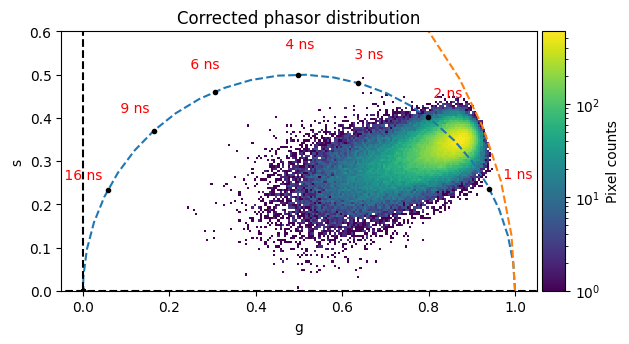

In [11]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")



## Tau-M / Tau-Phi Comparison

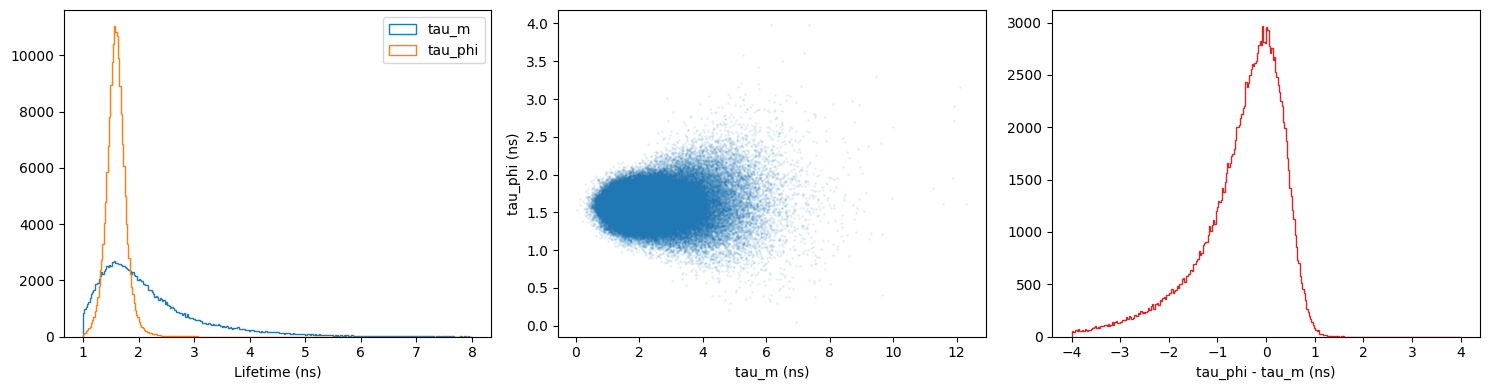

In [12]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare   = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare,   bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()



## Lifetime Visualization

/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

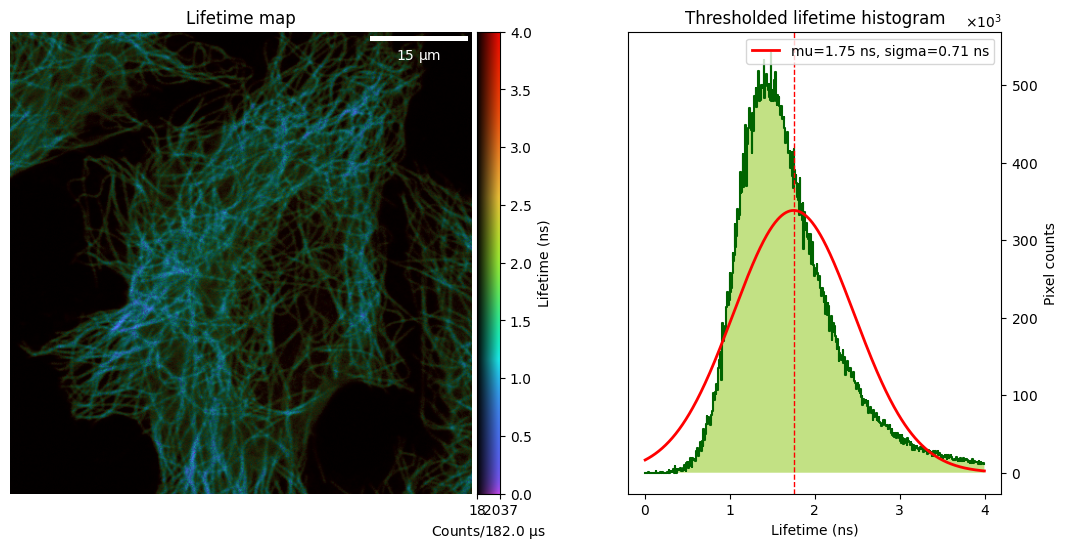

In [13]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[0, 4],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)



/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

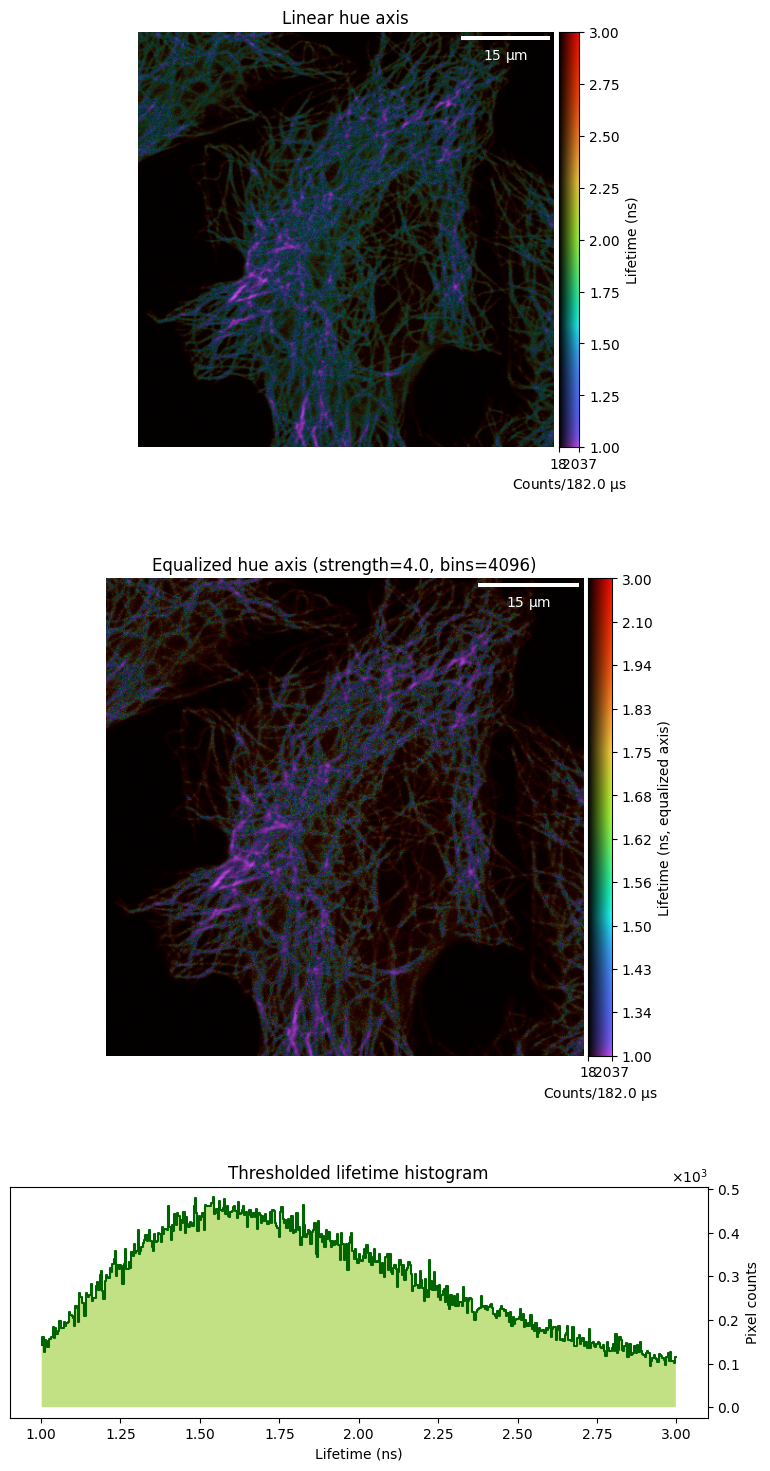

In [14]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 3.0],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)



## Optional Export

`EXPORT_PATH` = enter the path and file name where the phasor plot will be saved (`.h5` format)

```python
EXPORT_PATH = r'C:\Users\REPLACE_ME\Desktop\Convallaria_PHASOR.h5'
if EXPORT_PATH:
    with h5py.File(EXPORT_PATH, "w") as hf:
        hf["intensity_map"]    = intensity_map
        hf["real"]             = np.real(phasor_map)
        hf["imag"]             = np.imag(phasor_map)
        hf["signal"]           = data_summed
        hf["irf_phasor_real"]  = np.real(irf_phasor)
        hf["irf_phasor_imag"]  = np.imag(irf_phasor)
```

In [15]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)

